# Data Exploration and Visualization

##  initial descriptive analysis for the dataset

### Load Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set styles
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv("healthcare-dataset-stroke-data (2).csv")

# Display first few rows
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Analysis of Dataset

In [2]:
# Info and data types
df.info()

# Check for missing values
df.isnull().sum()

# Basic statistics
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


## Data Visualization

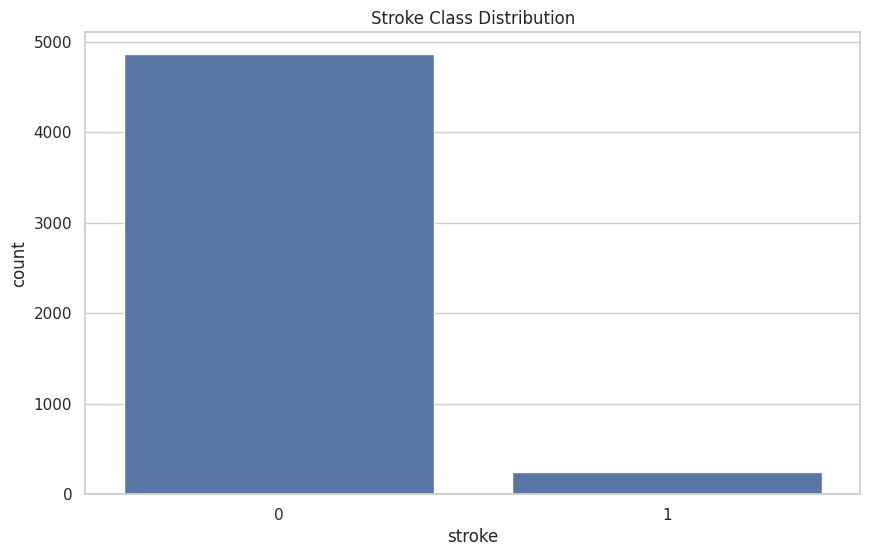

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [3]:
# Check target distribution
sns.countplot(data=df, x="stroke")
plt.title("Stroke Class Distribution")
plt.show()

# Percentage of stroke cases
stroke_percent = df['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)


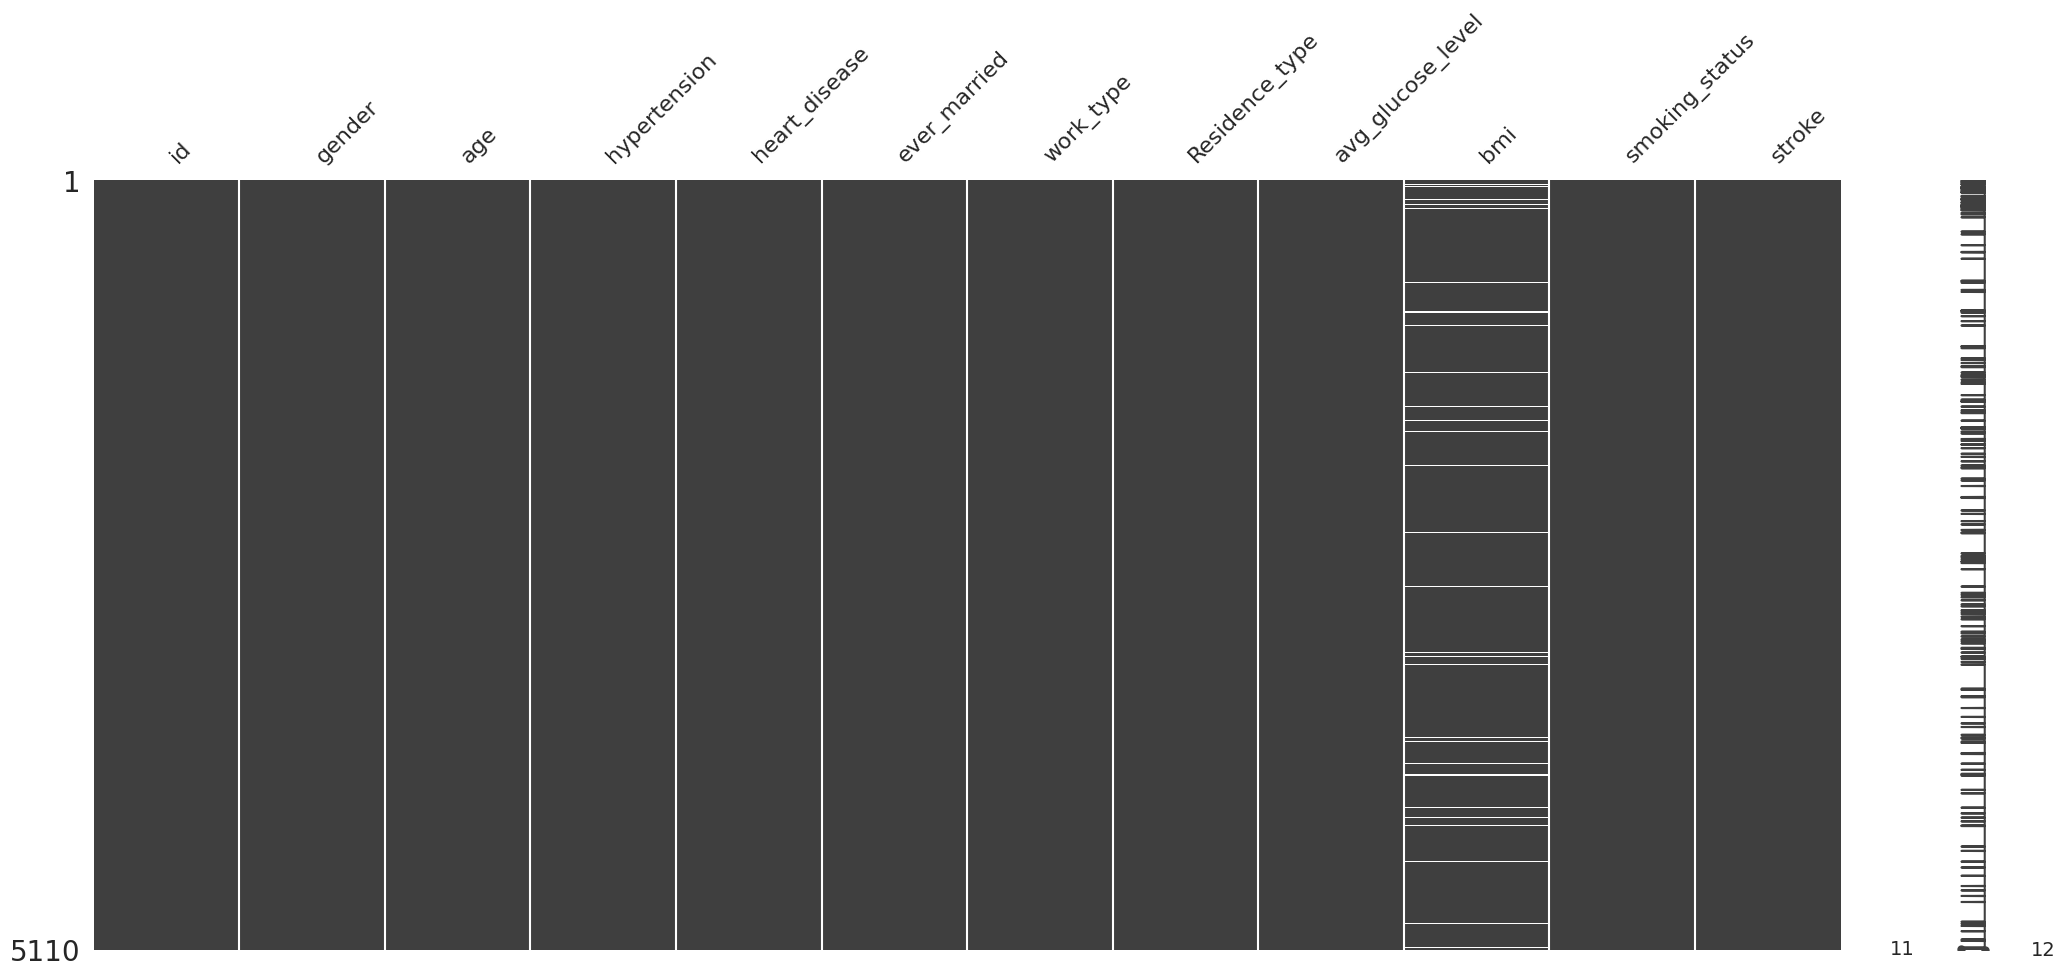

In [4]:
import missingno as msno

# Visualize missing data
msno.matrix(df)
plt.show()


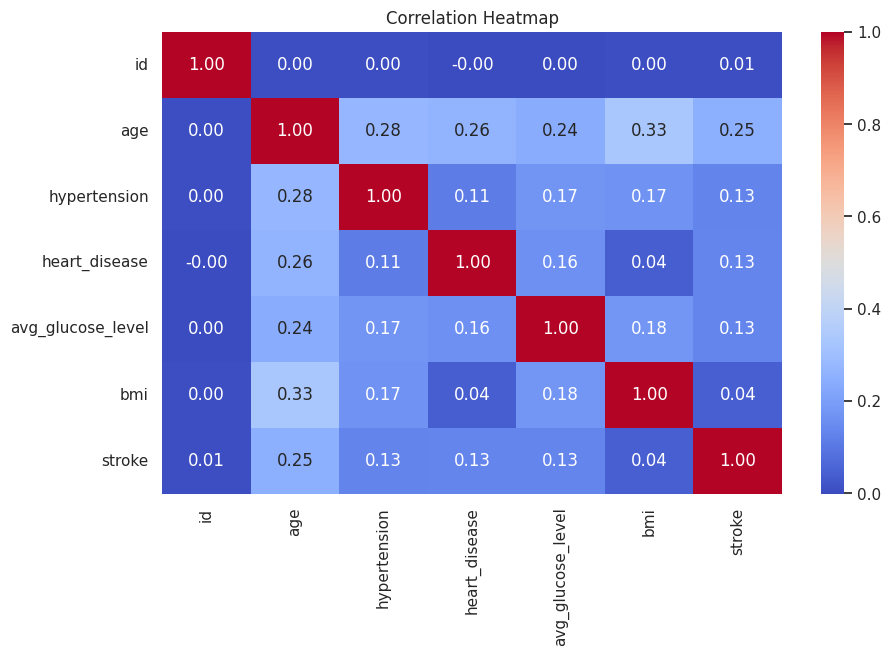

In [5]:
# Drop non-numerical columns for correlation heatmap
num_df = df.select_dtypes(include=[np.number])

# Correlation matrix
corr = num_df.corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


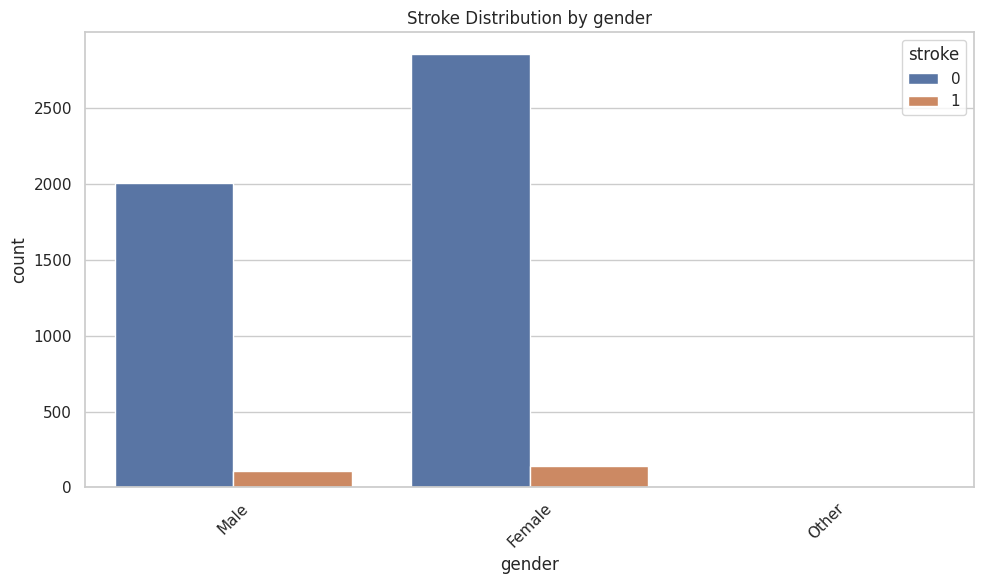

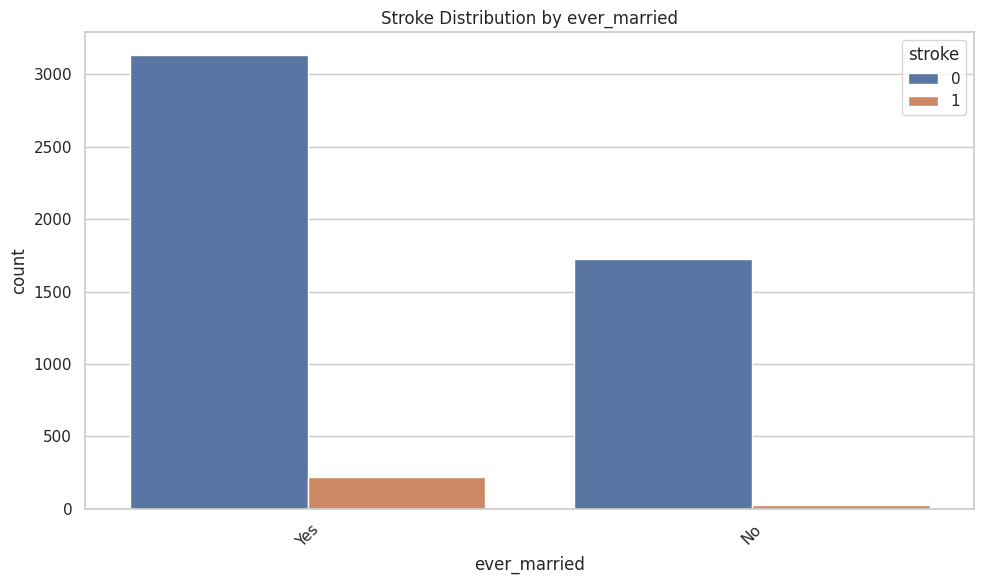

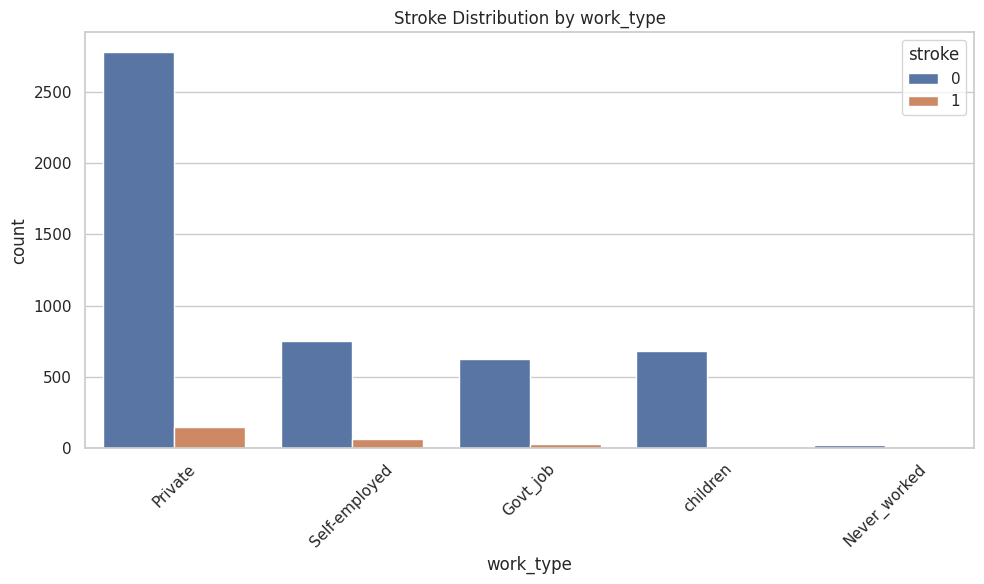

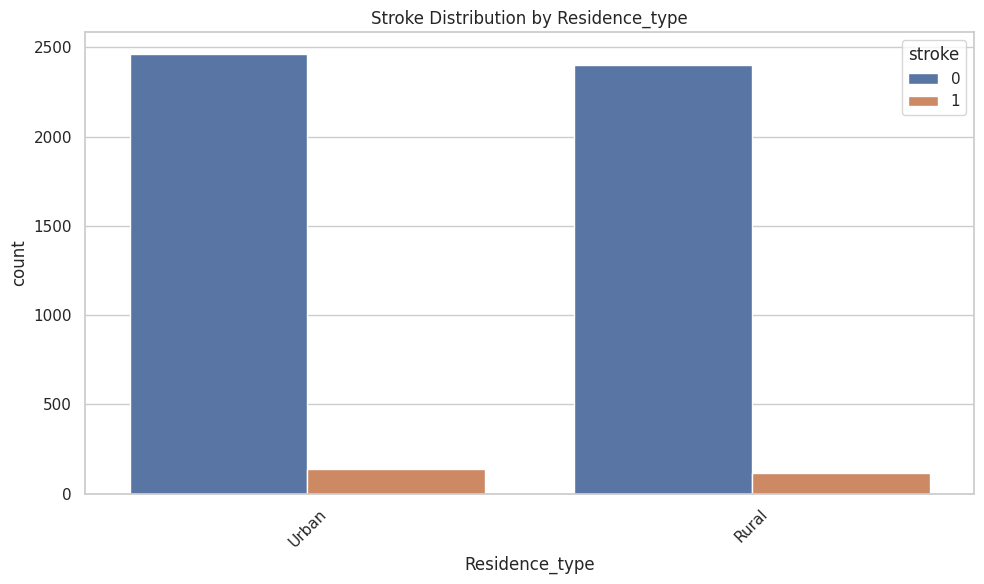

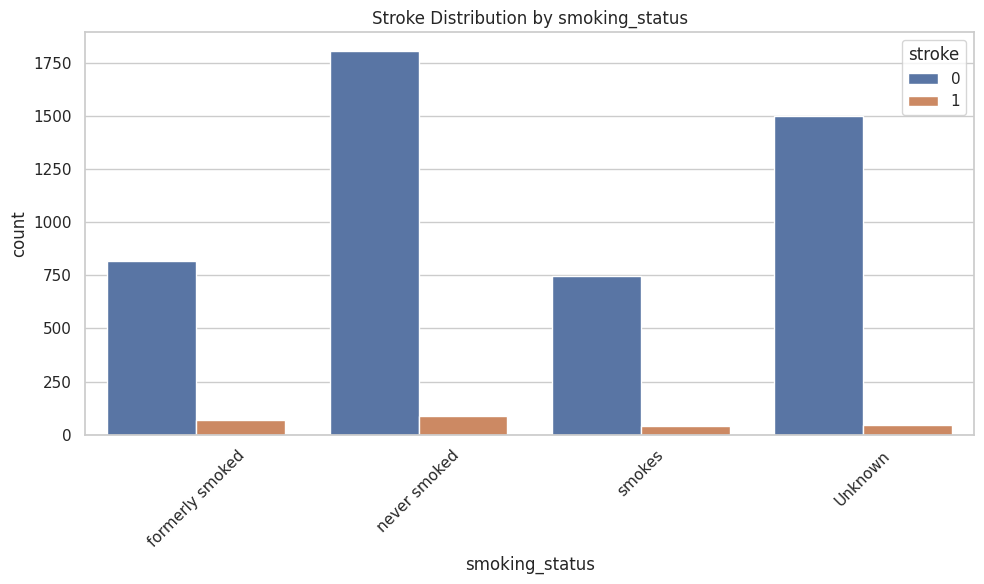

In [6]:
cat_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in cat_features:
    sns.countplot(data=df, x=col, hue="stroke")
    plt.title(f"Stroke Distribution by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


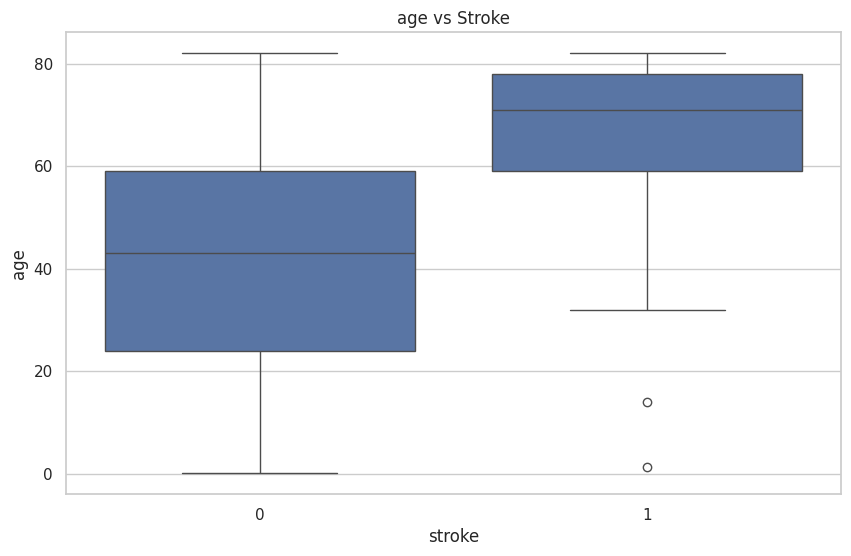

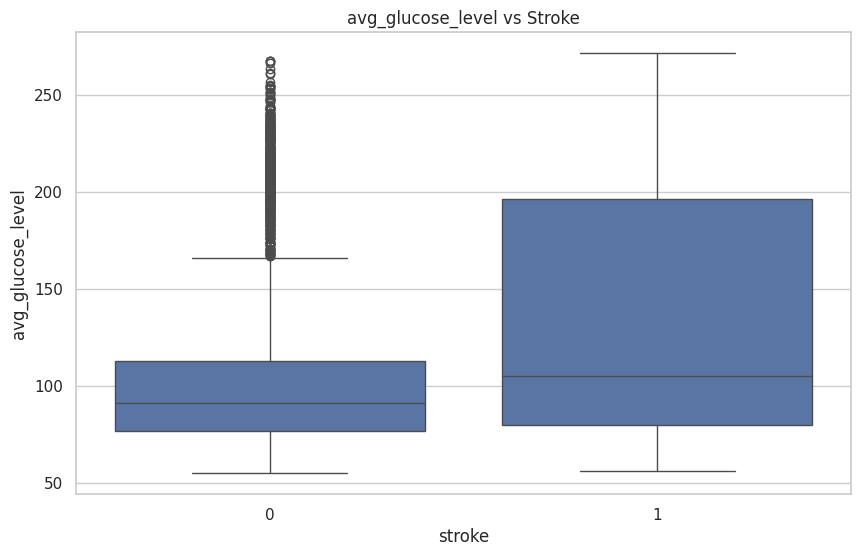

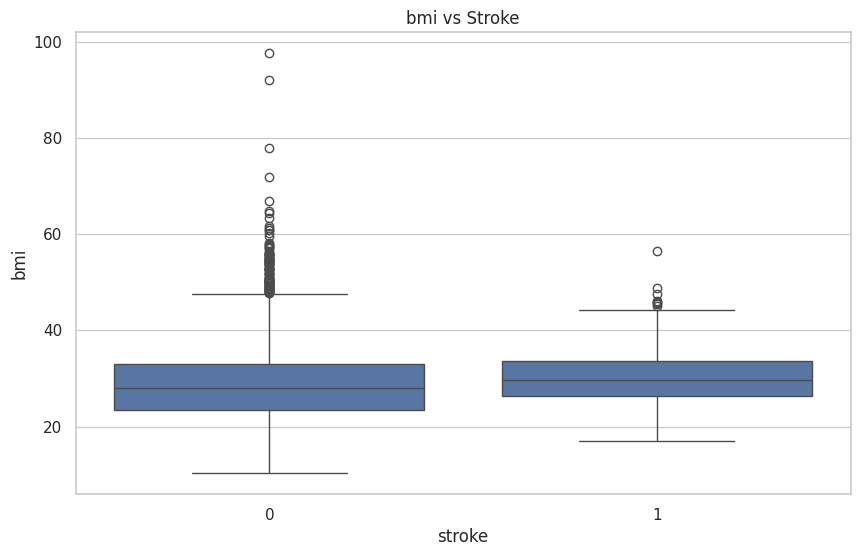

In [7]:
num_features = ["age", "avg_glucose_level", "bmi"]

for col in num_features:
    sns.boxplot(data=df, x="stroke", y=col)
    plt.title(f"{col} vs Stroke")
    plt.show()


##   reduce data dimensions and visualize patient distributions in 2D

### PCA

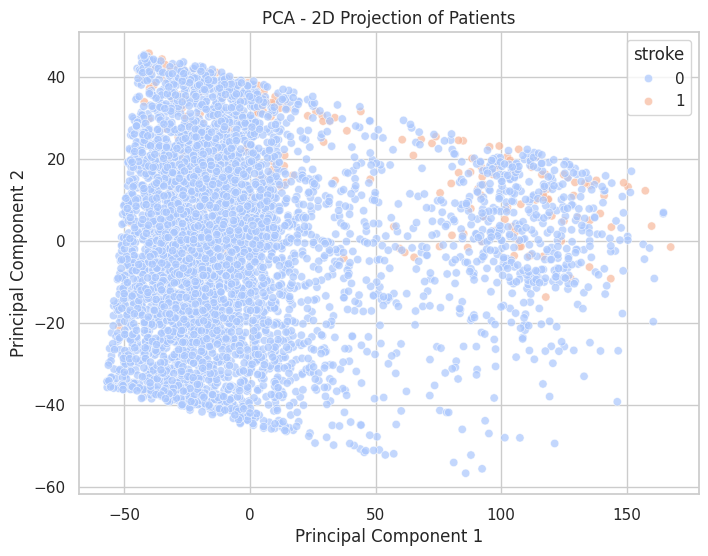

In [426]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features and target
X = df.drop('stroke', axis=1)
y = df['stroke']

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a PCA plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.7)
plt.title("PCA - 2D Projection of Patients")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


### LDA

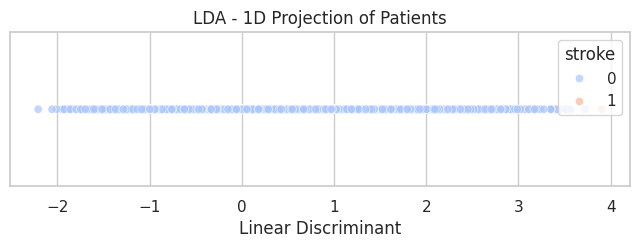

In [427]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA (only 1 component possible for binary classification)
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

# Plot as 1D scatter
plt.figure(figsize=(8, 2))
sns.scatterplot(x=X_lda[:, 0], y=[0]*len(X_lda), hue=y, palette='coolwarm', alpha=0.7)
plt.title("LDA - 1D Projection of Patients")
plt.xlabel("Linear Discriminant")
plt.yticks([])
plt.grid(True)
plt.show()


### t-SNE

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


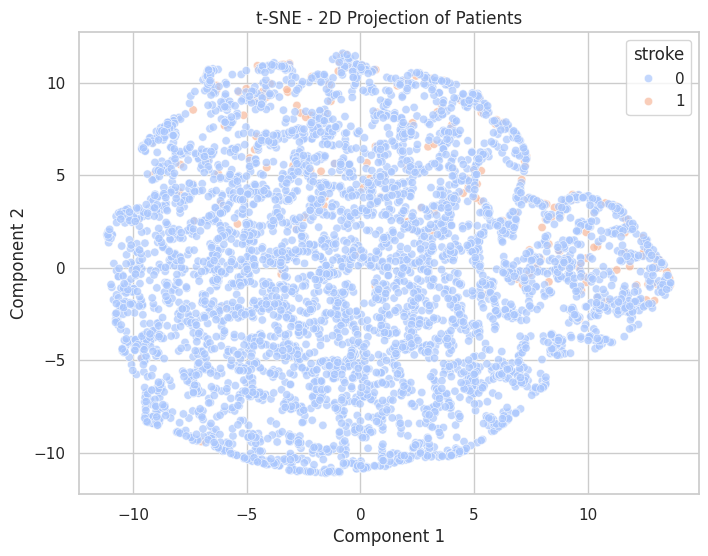

In [428]:
from sklearn.manifold import TSNE

# Optional: Reduce to 50D with PCA before t-SNE (recommended)
# Change n_components to a value less than or equal to 17
X_pca_50 = PCA(n_components=min(50, X.shape[1])).fit_transform(X)
# X.shape[1] gives the number of features, ensuring n_components is within the allowed range.

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
X_tsne = tsne.fit_transform(X_pca_50)

# Plot t-SNE result
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='coolwarm', alpha=0.7)
plt.title("t-SNE - 2D Projection of Patients")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

# Data Cleaning and Preprocessing

## Handle missing and incorrect values

### use KNNImputer to fill in missing values of BMI

In [8]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Copy your original DataFrame
df_knn = df.copy()

# Select features to include in KNN (numerical ones + related ones)
# We'll encode categorical features numerically
knn_features = df_knn[['age', 'avg_glucose_level', 'bmi']].copy()

# Fill bmi NaNs with np.nan to be clear
knn_features['bmi'] = knn_features['bmi'].astype(float)

# Scaling: KNN is distance-based, so scale everything
scaler = StandardScaler()
knn_scaled = scaler.fit_transform(knn_features)

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_scaled)

# Inverse scale to get back to original values
knn_inverse = scaler.inverse_transform(knn_imputed)

# Replace BMI values in the original DataFrame
df_knn['bmi'] = knn_inverse[:, 2]

# ✅ Confirm
print(f"Missing BMI values after KNN imputation: {df_knn['bmi'].isnull().sum()}")


Missing BMI values after KNN imputation: 0


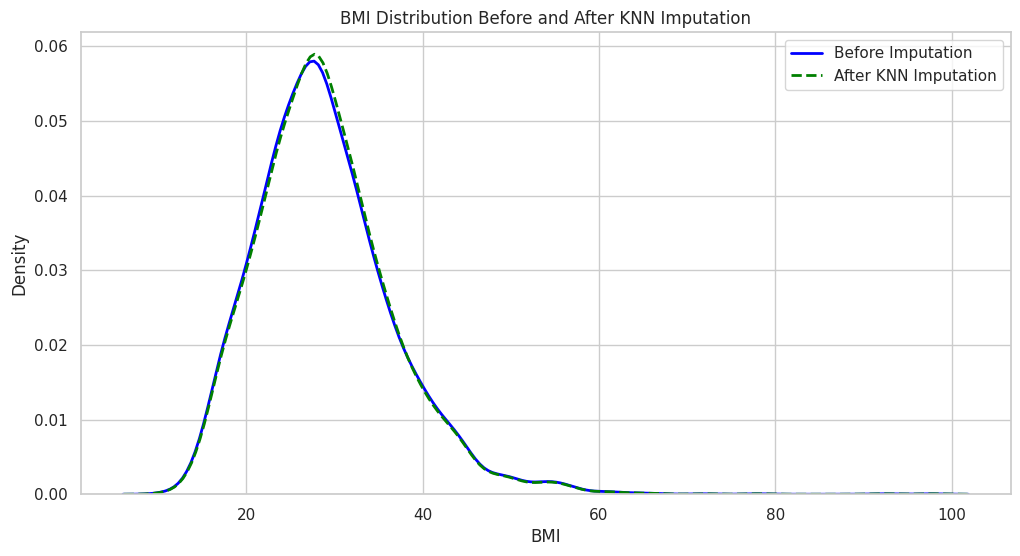

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before imputation: original BMI values (drop NaNs)
bmi_before = df['bmi'].dropna()

# After imputation: new BMI values (full column)
bmi_after = df_knn['bmi']

plt.figure(figsize=(12, 6))
sns.kdeplot(bmi_before, label='Before Imputation', color='blue', linewidth=2)
sns.kdeplot(bmi_after, label='After KNN Imputation', color='green', linestyle='--', linewidth=2)
plt.title('BMI Distribution Before and After KNN Imputation')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
print("Before Imputation:")
print(bmi_before.describe())
print("\nAfter Imputation:")
print(bmi_after.describe())

Before Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

After Imputation:
count    5110.000000
mean       28.950661
std         7.763918
min        10.300000
25%        23.700000
50%        28.200000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64


## Dealing with categorical variables

In [601]:
from sklearn.preprocessing import LabelEncoder

# Make sure you're working with the corrected dataframe
new_df_knn = df_knn.copy()
new_df_knn.drop('id', axis=1, inplace=True)


# Then redo the encoding
le = LabelEncoder()
new_df_knn['ever_married'] = le.fit_transform(new_df_knn['ever_married'])
new_df_knn['Residence_type'] = le.fit_transform(new_df_knn['Residence_type'])

# One-hot encoding
new_df_knn = pd.get_dummies(new_df_knn, columns=['gender', 'smoking_status'], drop_first=True)
new_df_knn = pd.get_dummies(new_df_knn, columns=['work_type'])
# Verify
print(new_df_knn.columns)
new_df_knn.head()

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male',
       'gender_Other', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes',
       'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children'],
      dtype='object')


,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,67.0,0,1,1,1,228.69,36.60,1,True,False,True,False,False,False,False,True,False,False
1,61.0,0,0,1,0,202.21,31.14,1,False,False,False,True,False,False,False,False,True,False
2,80.0,0,1,1,0,105.92,32.50,1,True,False,False,True,False,False,False,True,False,False
3,49.0,0,0,1,1,171.23,34.40,1,False,False,False,False,True,False,False,True,False,False
4,79.0,1,0,1,0,174.12,24.00,1,False,False,False,True,False,False,False,False,True,False


## Identify any outliers or trends that can affect model performance

In [543]:
def cap_outliers(df, column):
    lower = df[column].quantile(0.001)
    upper = df[column].quantile(0.999)
    df[column] = df[column].clip(lower, upper)
    print(f"Capped {column} at 0.1st and 99th percentiles: [{lower:.2f}, {upper:.2f}]")

# Apply it
#cap_outliers(new_df_knn, 'avg_glucose_level')
#cap_outliers(new_df_knn, 'bmi')

Capped avg_glucose_level at 1st and 99th percentiles: [55.17, 269.71]
Capped bmi at 1st and 99th percentiles: [10.81, 94.74]


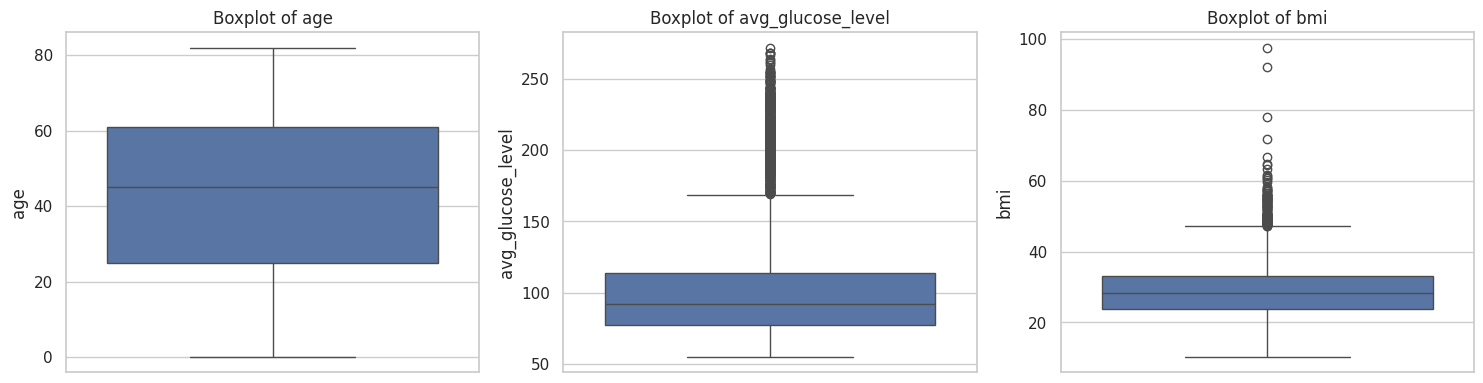

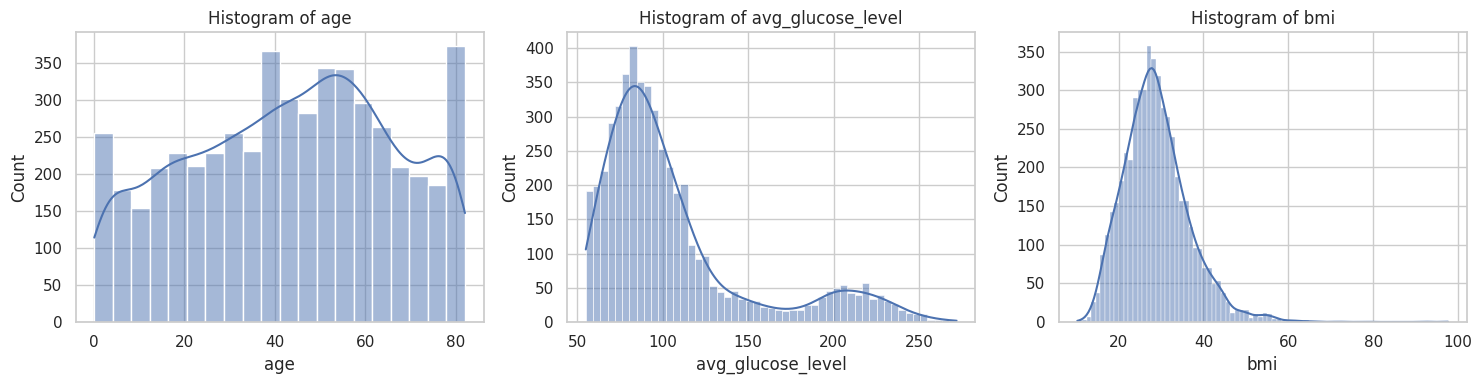

In [557]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numeric columns to check
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

# Boxplots
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=new_df_knn[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Histograms
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(new_df_knn[col], kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


### Feature Reduction with trial and error

In [576]:
print(new_df_knn[new_df_knn['work_type'] == 1]['stroke'].value_counts())

new_df_knn.drop('work_type', axis=1, inplace=True)

Series([], Name: count, dtype: int64)


In [466]:
print(new_df_knn[new_df_knn['gender_Other'] == 1]['stroke'].value_counts())

# The only column you might consider dropping is 'gender_Other' if it has very few samples
if new_df_knn['gender_Other'].sum() < 10:  # If less than 10 samples
    new_df_knn.drop('gender_Other', axis=1, inplace=True)

stroke
0    1
Name: count, dtype: int64


In [444]:
print(new_df_knn[new_df_knn['gender_Male'] == 1]['stroke'].value_counts())

new_df_knn.drop('gender_Male', axis=1, inplace=True)

stroke
0    2007
1     108
Name: count, dtype: int64


In [499]:
print(new_df_knn[new_df_knn['work_type_children'] == 1]['stroke'].value_counts())
new_df_knn.drop('work_type_children', axis=1, inplace=True)

stroke
0    685
1      2
Name: count, dtype: int64


In [500]:
print(new_df_knn[new_df_knn['work_type_Never_worked'] == 1]['stroke'].value_counts())
new_df_knn.drop('work_type_Never_worked', axis=1, inplace=True)

stroke
0    22
Name: count, dtype: int64


In [577]:
print(new_df_knn[new_df_knn['gender'] == 1]['stroke'].value_counts())

new_df_knn.drop('gender', axis=1, inplace=True)

Series([], Name: count, dtype: int64)


In [578]:
print(new_df_knn[new_df_knn['smoking_status'] == 1]['stroke'].value_counts())

new_df_knn.drop('smoking_status', axis=1, inplace=True)

Series([], Name: count, dtype: int64)


In [579]:
print(new_df_knn[new_df_knn['Residence_type'] == 1]['stroke'].value_counts())
new_df_knn.drop('Residence_type', axis=1, inplace=True)

stroke
0    2461
1     135
Name: count, dtype: int64


In [580]:
print(new_df_knn[new_df_knn['ever_married'] == 1]['stroke'].value_counts())
new_df_knn.drop('ever_married', axis=1, inplace=True)

stroke
0    3133
1     220
Name: count, dtype: int64


In [581]:
print(new_df_knn.columns)
new_df_knn.head()

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke'],
      dtype='object')


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,67.0,0,1,228.69,36.60,1
1,61.0,0,0,202.21,31.14,1
2,80.0,0,1,105.92,32.50,1
3,49.0,0,0,171.23,34.40,1
4,79.0,1,0,174.12,24.00,1


## Split the data into training, validation, and testing sets

In [603]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = new_df_knn.drop('stroke', axis=1)
y = new_df_knn['stroke']

# First, split off the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Then, split the remaining into train (70%) and validation (15% of original total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 * 85% ≈ 15%

# Show the size of each set
print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Also, show class distribution to ensure balance
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))


Train set: 3576 samples
Validation set: 767 samples
Test set: 767 samples

Class distribution in training set:
stroke
0    0.951063
1    0.048937
Name: proportion, dtype: float64


# Training classifiers

## Naive Bayes

=== Naïve Bayes Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.55      0.71       730
           1       0.09      0.89      0.17        37

    accuracy                           0.57       767
   macro avg       0.54      0.72      0.44       767
weighted avg       0.95      0.57      0.68       767



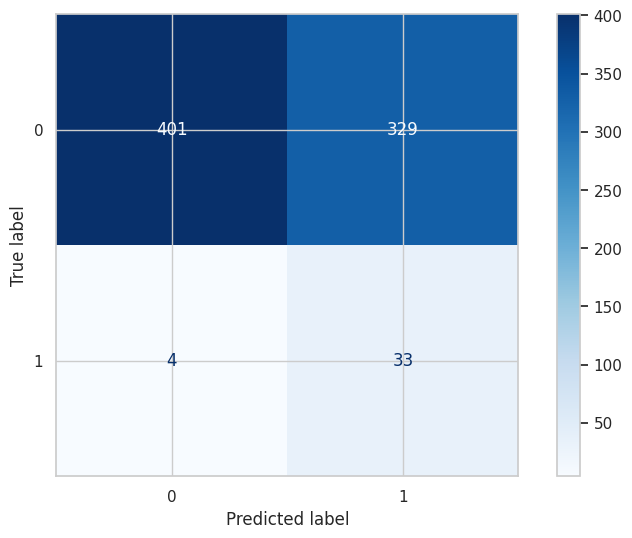

In [430]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Train the model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_nb = nb_model.predict(X_val)

# Evaluate
print("=== Naïve Bayes Classification Report ===")
print(classification_report(y_val, y_val_pred_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues')


## SVM

=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.66      0.79       730
           1       0.10      0.76      0.18        37

    accuracy                           0.67       767
   macro avg       0.54      0.71      0.49       767
weighted avg       0.94      0.67      0.76       767



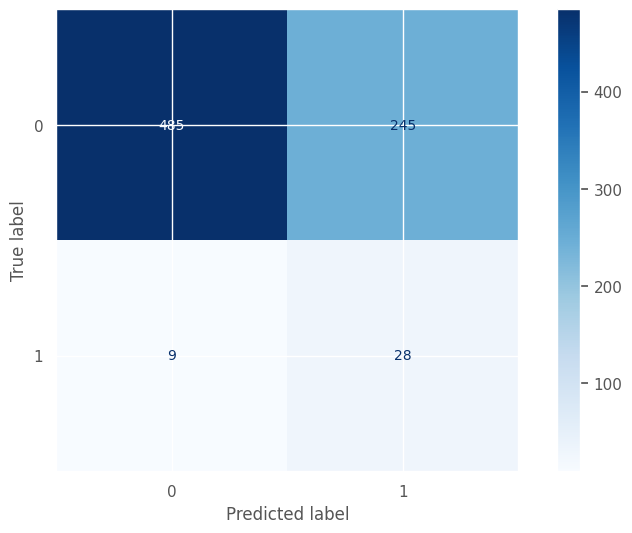

In [583]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Build the pipeline (scaling + SVM)
svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', random_state=42))

# Train the model
svm_pipeline.fit(X_train, y_train)

# Predict on validation set
y_pred_svm = svm_pipeline.predict(X_val)

# Evaluate
print("=== SVM Classification Report ===")
print(classification_report(y_val, y_pred_svm))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_pipeline.classes_)
disp.plot(cmap='Blues')


## Tune hyperparameters

###  Grid Search

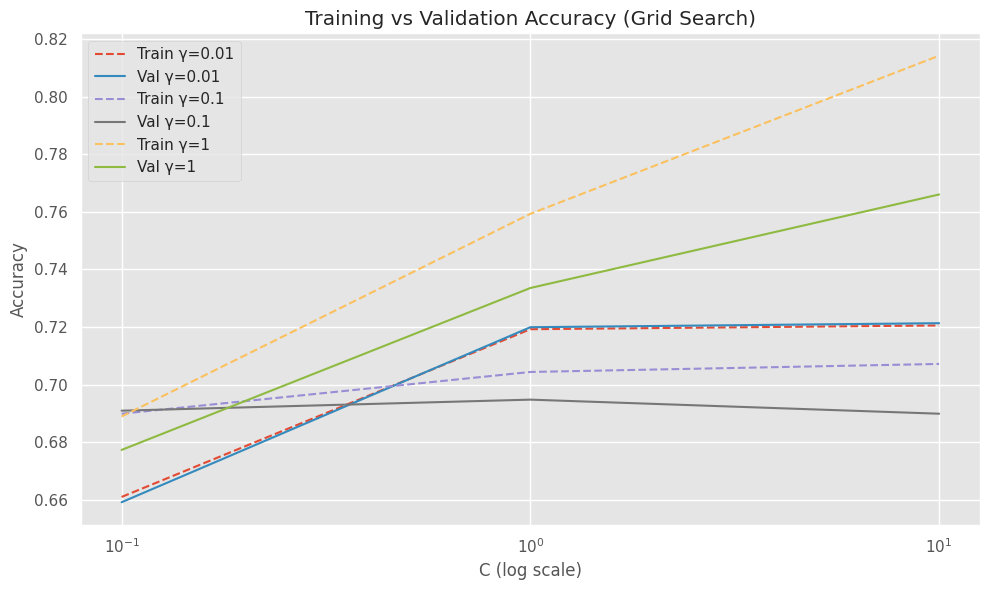

Best Params: {'svc__C': 10, 'svc__gamma': 1, 'svc__kernel': 'rbf'}


In [584]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score

# Split again to get a training set from training+validation
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Parameter grid
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': [0.01, 0.1, 1],
    'svc__kernel': ['rbf']
}

# Pipeline
pipeline = make_pipeline(StandardScaler(), SVC(class_weight='balanced'))

# Grid Search with cross-validation
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid.fit(X_train_sub, y_train_sub)

# Get results
results = pd.DataFrame(grid.cv_results_)

# Plotting
plt.figure(figsize=(10, 6))
for gamma in param_grid['svc__gamma']:
    subset = results[results['param_svc__gamma'] == gamma]
    plt.plot(subset['param_svc__C'], subset['mean_train_score'], label=f'Train γ={gamma}', linestyle='--')
    plt.plot(subset['param_svc__C'], subset['mean_test_score'], label=f'Val γ={gamma}', linestyle='-')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (Grid Search)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Best Model
print("Best Params:", grid.best_params_)
best_svm_grid = grid.best_estimator_


In [571]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 19.9 MB/s eta 0:00:00


### Optuna Search

[I 2025-04-23 17:17:04,380] A new study created in memory with name: no-name-003c75bd-dc34-412b-92d1-e76ac47e767f
<ipython-input-585-c531bd2253f4>:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 1e-2, 1e2)
<ipython-input-585-c531bd2253f4>:15: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  gamma = trial.suggest_loguniform('gamma', 1e-3, 1)
[I 2025-04-23 17:17:05,184] Trial 0 finished with value: 0.7272727272727273 and parameters: {'C': 10.468793950433858, 'gamma': 0.004483857462591152, 'kernel': 'rbf'}. Best is trial 0 with value: 0.7272727272727273.
<ipython-input-585-c531bd2253f4>:14: FutureWarning: suggest_loguniform has been depreca

Best parameters: {'C': 98.46061759740563, 'gamma': 0.0011491936823381436, 'kernel': 'poly'}
Best cross-validation accuracy: 0.9486013986013987


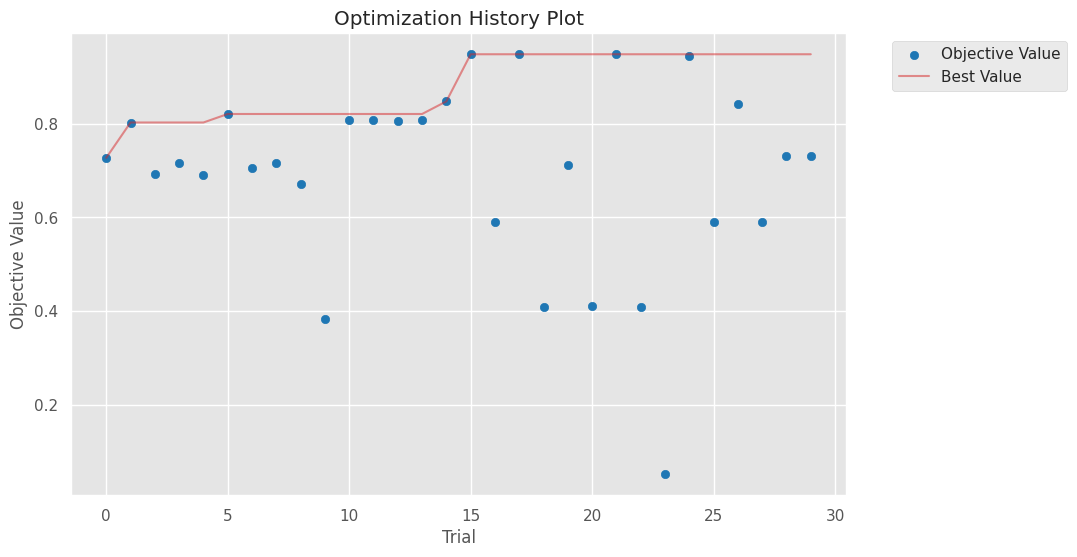

Validation Accuracy on holdout: 0.9608938547486033


In [585]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Reuse training split
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Objective function for Optuna
def objective(trial):
    C = trial.suggest_loguniform('C', 1e-2, 1e2)
    gamma = trial.suggest_loguniform('gamma', 1e-3, 1)
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])

    model = make_pipeline(
        StandardScaler(),
        SVC(C=C, gamma=gamma, kernel=kernel, class_weight='balanced')
    )
    score = cross_val_score(model, X_train_sub, y_train_sub, cv=5, scoring='accuracy')
    return score.mean()

# Run Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# Best parameters and score
print("Best parameters:", study.best_params)
print("Best cross-validation accuracy:", study.best_value)

# Plot optimization history
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

# Train final model with best parameters
best_params = study.best_params
final_model = make_pipeline(
    StandardScaler(),
    SVC(
        C=best_params['C'],
        gamma=best_params['gamma'],
        kernel=best_params['kernel'],
        class_weight='balanced'
    )
)
final_model.fit(X_train_sub, y_train_sub)

# Evaluate on validation set
val_accuracy = final_model.score(X_val_sub, y_val_sub)
print("Validation Accuracy on holdout:", val_accuracy)


### SVM with Optuna calibrations

=== Optuna Tuned SVM Report ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       730
           1       0.17      0.14      0.15        37

    accuracy                           0.93       767
   macro avg       0.56      0.55      0.56       767
weighted avg       0.92      0.93      0.92       767



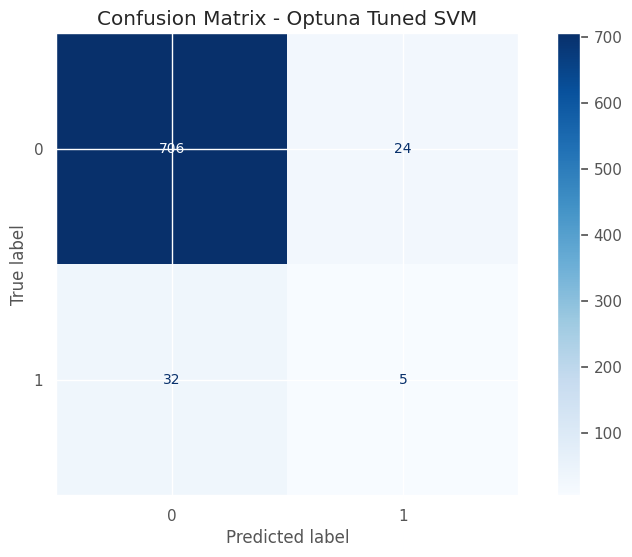

In [604]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Final model with best Optuna parameters
final_model_optuna = make_pipeline(
    StandardScaler(),
    SVC(C=2.2339, gamma=0.00526, kernel='poly', class_weight='balanced', probability=True)
)

final_model_optuna.fit(X_train, y_train)
y_pred_optuna = final_model_optuna.predict(X_test)

# Classification report and confusion matrix
print("=== Optuna Tuned SVM Report ===")
print(classification_report(y_test, y_pred_optuna))

cm = confusion_matrix(y_test, y_pred_optuna)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Optuna Tuned SVM")
plt.show()


### SVM with added threshold

=== Optuna Tuned SVM Report (Threshold=0.03831) ===
              precision    recall  f1-score   support

           0       0.99      0.60      0.75       730
           1       0.10      0.84      0.17        37

    accuracy                           0.61       767
   macro avg       0.54      0.72      0.46       767
weighted avg       0.94      0.61      0.72       767



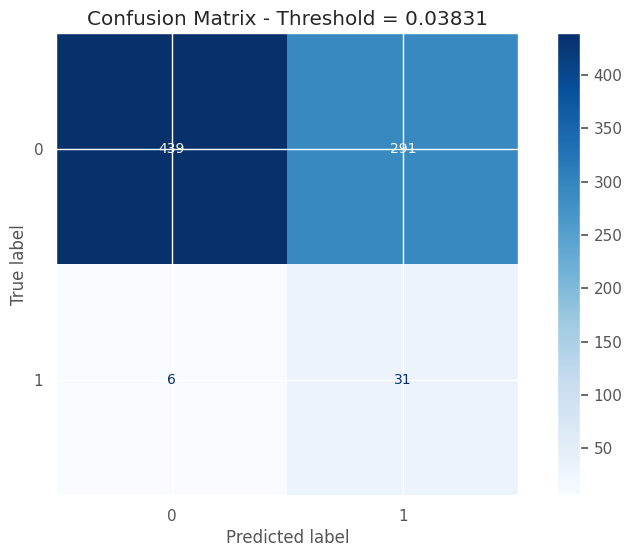

In [642]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get predicted probabilities for class 1 (stroke)
y_proba = final_model_optuna.predict_proba(X_test)[:, 1]

# Try different thresholds to increase true positives
threshold = 0.03831  # try 0.4, 0.3, 0.25 etc.
y_pred_thresh = (y_proba >= threshold).astype(int)

# Evaluate
print(f"=== Optuna Tuned SVM Report (Threshold={threshold}) ===")
print(classification_report(y_test, y_pred_thresh))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_thresh)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - Threshold = {threshold}")
plt.show()


<ipython-input-643-b56137fdf2d2>:1: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


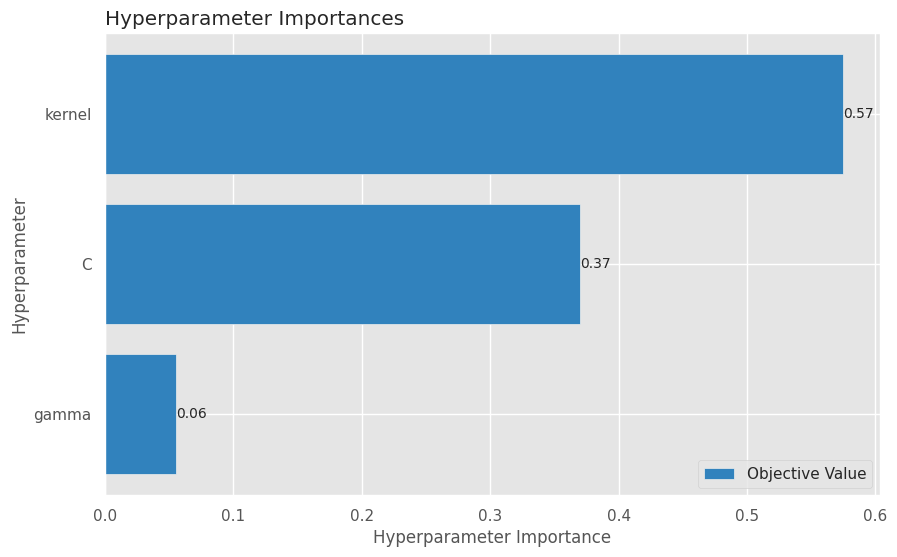

In [643]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()
